# Reference implementation of Deep Q-Learning

This notebook includes an implementation of the Deep Q-learning algorithm for the Cartpole problem (see [Cartpole documentation](https://gymnasium.farama.org/environments/classic_control/cart_pole/)).


## Libraries

In [3]:
!pip install gymnasium[classic-control]

import gymnasium as gym
import numpy as np
from tensorflow import keras
import matplotlib.pyplot as plt
import time
import random
import math

## Hyperparameters

In [5]:
# Learning rate
LEARNING_RATE = 0.001
# Batch size
BATCH_SIZE = 64
# Discount factor gamma
GAMMA = 0.99
# Size of the replay memory (replay buffer) that saves transitions
MEMORY_SIZE = 100000
# Values related to the exploration rate used by the epsilon-greedy policy
EXPLORATION_RATE_MAX = 1
EXPLORATION_RATE_MIN = 0.01
EXPLORATION_RATE_DECAY = 0.98
# Maximum number of episodes for training
MAX_EPISODES_FOR_TRAINING = 600
# Goal score to be achieved during the training process
TRAINING_GOAL = 400
# Number of episodes used to check the goal score during the training process
EPISODES_TO_CHECK_TRAINING_GOAL = 10
# Number of episodes used to evaluate the model performance after training
EPISODES_TO_EVALUATE_MODEL_PERFORMANCE = 30

## Class ReplayMemory

Memory of transitions for experience replay.

In [7]:
class ReplayMemory:

    def __init__(self,number_of_observations):
        # Create replay memory
        self.states = np.zeros((MEMORY_SIZE, number_of_observations))
        self.states_next = np.zeros((MEMORY_SIZE, number_of_observations))
        self.actions = np.zeros(MEMORY_SIZE, dtype=np.int32)
        self.rewards = np.zeros(MEMORY_SIZE)
        self.terminal_states = np.zeros(MEMORY_SIZE, dtype=bool)
        self.current_size=0

    def store_transition(self, state, action, reward, state_next, terminal_state):
        # Store a transition (s,a,r,s') in the replay memory
        i = self.current_size
        self.states[i] = state
        self.states_next[i] = state_next
        self.actions[i] = action
        self.rewards[i] = reward
        self.terminal_states[i] = terminal_state
        self.current_size = i + 1

    def sample_memory(self, batch_size):
        # Generate a sample of transitions from the replay memory
        batch = np.random.choice(self.current_size, batch_size)
        states = self.states[batch]
        states_next = self.states_next[batch]
        rewards = self.rewards[batch]
        actions = self.actions[batch]
        terminal_states = self.terminal_states[batch]
        return states, actions, rewards, states_next, terminal_states

## Class DQN

Reinforcement learning agent with a Deep Q-Network.

In [9]:
class DQN:

    def __init__(self, number_of_observations, number_of_actions):
        # Initialize variables and create neural model
        self.number_of_actions = number_of_actions
        self.number_of_observations = number_of_observations
        self.scores = []
        self.memory = ReplayMemory(number_of_observations)

        # Neural model
        self.model = keras.models.Sequential()
        self.model.add(keras.layers.InputLayer(shape=(number_of_observations,)))
        self.model.add(keras.layers.Dense(32, activation="relu",kernel_initializer="he_normal"))
        self.model.add(keras.layers.Dense(32, activation="relu",kernel_initializer="he_normal"))
        self.model.add(keras.layers.Dense(number_of_actions, activation="linear"))
        self.model.compile(loss="mse", optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE))

    def remember(self, state, action, reward, next_state, terminal_state):
        # Store a tuple (s, a, r, s') for experience replay
        state = np.reshape(state, [1, self.number_of_observations])
        next_state = np.reshape(next_state, [1, self.number_of_observations])
        self.memory.store_transition(state, action, reward, next_state, terminal_state)

    def select_epsilon_greedy_policy(self, state, exploration_rate):
        # Generate an action for a given state using epsilon-greedy policy
        if np.random.rand() < exploration_rate:
            return random.randrange(self.number_of_actions)
        else:
            state = np.reshape(state, [1, self.number_of_observations])
            q_values = self.model(state).numpy()
            return np.argmax(q_values[0])

    def select_greedy_policy(self, state):
        # Generate an action for a given state using greedy policy
        state = np.reshape(state, [1, self.number_of_observations])
        q_values = self.model(state).numpy()
        return np.argmax(q_values[0])

    def learn(self):
        # Learn the value Q using a sample of examples from the replay memory
        if self.memory.current_size < BATCH_SIZE: return

        states, actions, rewards, next_states, terminal_states = self.memory.sample_memory(BATCH_SIZE)

        q_targets = self.model(states).numpy()
        q_next_states = self.model(next_states).numpy()

        for i in range(BATCH_SIZE):
             if (terminal_states[i]):
                  q_targets[i][actions[i]] = rewards[i]
             else:
                  q_targets[i][actions[i]] = rewards[i] + GAMMA * np.max(q_next_states[i])

        self.model.train_on_batch(states, q_targets)

    def add_score(self, score):
        # Add the obtained score to a list to be presented later
        self.scores.append(score)

    def delete_scores(self):
        # Delete the scores
        self.scores = []

    def average_score(self, number_of_episodes):
        # Compute average score of the last episodes
        index = len(agent.scores) - number_of_episodes
        return np.mean(self.scores[max(0,index):(len(agent.scores))])

    def display_scores_graphically(self):
        # Display the obtained scores graphically
        plt.plot(self.scores)
        plt.xlabel("Episode")
        plt.ylabel("Score")
        
    def save_model(self):
        # Save model in format .keras
        self.model.save('my_model.keras')

## Auxiliary function

In [11]:
def print_time(time):
    min = round(time // 60)
    sec = round(time % 60)
    if min > 0:
        print(f"{min} min {sec} seconds")
    else:
        print(f"{sec} seconds")

## Environment

In [13]:
def create_environment():
    # Create simulated environment
    environment = gym.make("CartPole-v1")
    number_of_observations = environment.observation_space.shape[0]
    number_of_actions = environment.action_space.n
    return environment, number_of_observations, number_of_actions

## Program for training

Episode   1: score  24 (exploration rate: 1.000, average score:  24, transitions: 24)
Episode   2: score  85 (exploration rate: 0.980, average score:  54, transitions: 109)
Episode   3: score  22 (exploration rate: 0.960, average score:  44, transitions: 131)
Episode   4: score  22 (exploration rate: 0.941, average score:  38, transitions: 153)
Episode   5: score  18 (exploration rate: 0.922, average score:  34, transitions: 171)
Episode   6: score  18 (exploration rate: 0.904, average score:  32, transitions: 189)
Episode   7: score  24 (exploration rate: 0.886, average score:  30, transitions: 213)
Episode   8: score  54 (exploration rate: 0.868, average score:  33, transitions: 267)
Episode   9: score  24 (exploration rate: 0.851, average score:  32, transitions: 291)
Episode  10: score  46 (exploration rate: 0.834, average score:  34, transitions: 337)
Episode  11: score  17 (exploration rate: 0.817, average score:  33, transitions: 354)
Episode  12: score  10 (exploration rate: 0.

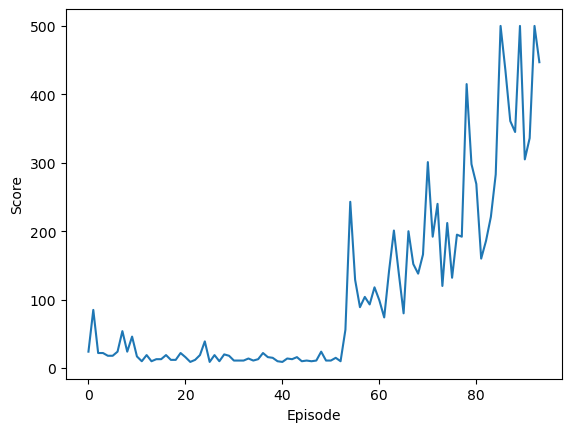

In [15]:
environment, number_of_observations, number_of_actions = create_environment()
agent = DQN(number_of_observations, number_of_actions)
episode = 0
start_time = time.perf_counter()
total_steps = 0
exploration_rate = EXPLORATION_RATE_MAX
goal_reached = False
while (episode < MAX_EPISODES_FOR_TRAINING) and not(goal_reached):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state
        action = agent.select_epsilon_greedy_policy(state, exploration_rate)

        # Execute the action on the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)

        total_steps += 1
        
        # Store in memory the transition (s,a,r,s')
        agent.remember(state, action, reward, state_next, terminal_state)

        score += reward

        # Learn using a batch of experience stored in memory
        agent.learn()

        # Detect end of episode
        if terminal_state or truncated:
            end_episode = True
            agent.add_score(score)
            average_score = agent.average_score(EPISODES_TO_CHECK_TRAINING_GOAL)
            if average_score >= TRAINING_GOAL: goal_reached = True
            print("Episode {0:>3}: ".format(episode), end = '')
            print("score {0:>3} ".format(math.trunc(score)), end = '')
            print("(exploration rate: %.3f, " % exploration_rate, end = '')
            print("average score: {0:>3}, ".format(round(average_score)), end = '')
            print("transitions: " + str(agent.memory.current_size) + ")")
        else:
            state = state_next
            
    # Decrease exploration rate
    exploration_rate *= EXPLORATION_RATE_DECAY
    exploration_rate = max(EXPLORATION_RATE_MIN, exploration_rate)

print("Time for training: ", end = '')
print_time(time.perf_counter() - start_time)
print("Total steps: ", total_steps)
print("Score (average last episodes):", round(average_score))
print("Score (max):", round(max(agent.scores)))

agent.display_scores_graphically()

agent.save_model()


## Testing program



In [17]:
episode = 0
score_list = []
while (episode < EPISODES_TO_EVALUATE_MODEL_PERFORMANCE):
    episode += 1
    score = 0
    state, info = environment.reset()
    end_episode = False
    while not(end_episode):
        # Select an action for the current state
        action = agent.select_greedy_policy(state)

        # Execute the action in the environment
        state_next, reward, terminal_state, truncated, info = environment.step(action)
        
        score += reward
        state = state_next
        end_episode = terminal_state or truncated
        
    score_list.append(score)
    print("Episode {0:>3}: ".format(episode), end = '')
    print("score {0:>3} \n".format(round(score)), end = '')
                
print("Score (average):", round(np.mean(score_list)))

Episode   1: score 254 
Episode   2: score 500 
Episode   3: score 414 
Episode   4: score 341 
Episode   5: score 455 
Episode   6: score 500 
Episode   7: score 322 
Episode   8: score 364 
Episode   9: score 467 
Episode  10: score 500 
Episode  11: score 449 
Episode  12: score 500 
Episode  13: score 331 
Episode  14: score 237 
Episode  15: score 423 
Episode  16: score 405 
Episode  17: score 382 
Episode  18: score 373 
Episode  19: score 444 
Episode  20: score 473 
Episode  21: score 500 
Episode  22: score 500 
Episode  23: score 397 
Episode  24: score 500 
Episode  25: score 225 
Episode  26: score 500 
Episode  27: score 500 
Episode  28: score 500 
Episode  29: score 319 
Episode  30: score 500 
Score (average): 419
